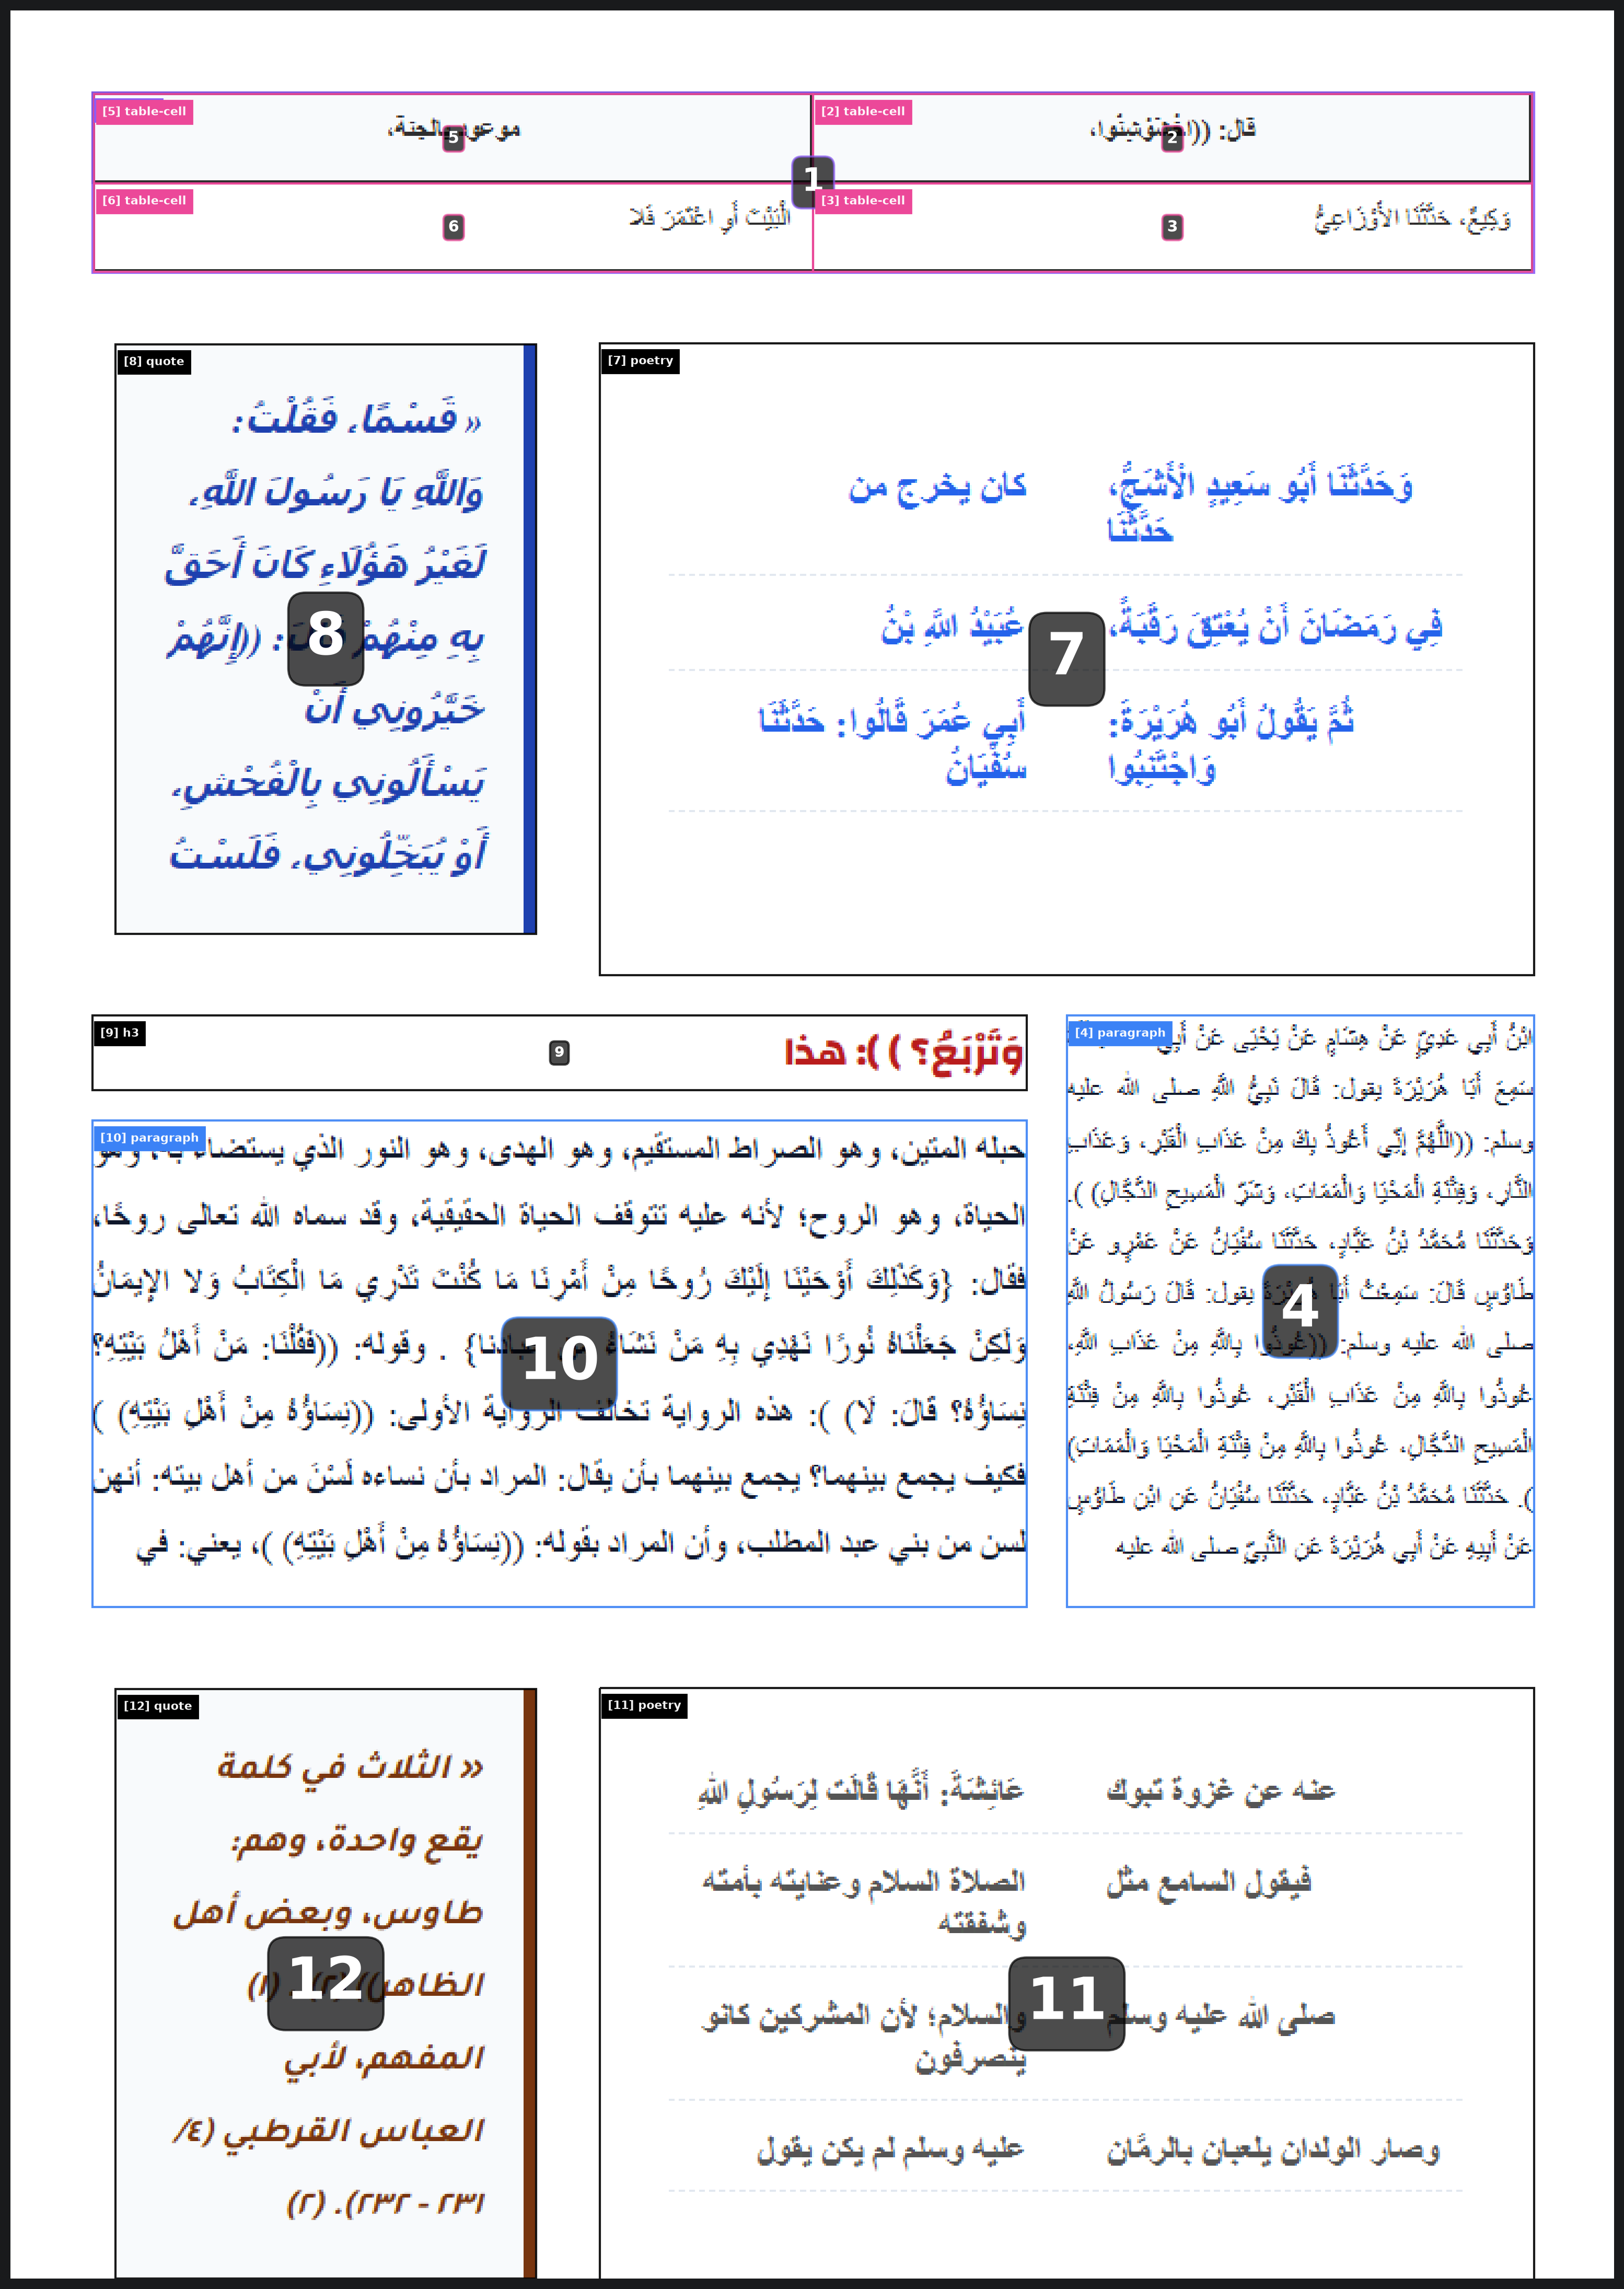

In [35]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_sample(sample_name, dataset_dir="dataset"):
    """
    Scans the dataset and visualizes the hierarchical bounding boxes.
    Expert styling applied: Parents (-1) get no center index, Children (>0) get flat sequential indices.
    """
    image_path = os.path.join(dataset_dir, "images", f"{sample_name}.png")
    json_path = os.path.join(dataset_dir, "annotations", f"{sample_name}.json")

    if not os.path.exists(image_path) or not os.path.exists(json_path):
        print(f"Error: Could not find files for {sample_name}")
        return

    # Load the Image and JSON
    img = Image.open(image_path)
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Setup the plot
    fig, ax = plt.subplots(1, figsize=(16, 22), dpi=200)
    ax.imshow(img)

    # Color coding for different layout blocks
    color_map = {
        'heading': '#ef4444',
        'paragraph': '#3b82f6',
        'multi-column': '#0ea5e9',
        'figure': '#10b981',
        'figure-image': '#059669',
        'figure-caption': '#f59e0b',
        'table': '#8b5cf6',
        'table-cell': '#ec4899'
    }

    # Draw the bounding boxes
    for box in data['boxes']:
        x, y, w, h = box['x'], box['y'], box['width'], box['height']
        label = box['label']
        reading_index = box.get('reading_index', -1)

        is_parent = (reading_index == -1)

        color = color_map.get(label, '#000000')

        # ==========================================
        # 1. BOX STYLING
        # ==========================================
        # Parents get thick dashed lines, Children get thinner solid lines
        lw = 3 if is_parent else 1.5
        ls = 'dashed' if is_parent else 'solid'

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=lw,
            linestyle=ls,
            edgecolor=color,
            facecolor='none',
            alpha=0.9
        )
        ax.add_patch(rect)

        # ==========================================
        # 2. TAG STYLING & POSITION
        # ==========================================
        # Parent tags go OUTSIDE (above), Child tags go INSIDE (below top edge)
        if is_parent:
            tag_y = y - 6
            tag_x = x
            va = 'bottom'
            fs = 10
            tag_text = label # No index shown for parents
        else:
            tag_y = y + 6
            tag_x = x + 4
            va = 'top'
            fs = 8
            tag_text = f"[{reading_index}] {label}"

        ax.text(
            tag_x, tag_y,
            tag_text,
            color='white',
            fontsize=fs,
            weight='bold',
            backgroundcolor=color,
            va=va,
            alpha=0.95
        )

        # ==========================================
        # 3. CENTER INDEX STYLING (CHILDREN ONLY)
        # ==========================================
        if not is_parent:
            center_x = x + (w / 2)
            center_y = y + (h / 2)

            dynamic_fontsize = max(10, min(w, h) * 0.25)
            dynamic_fontsize = min(40, dynamic_fontsize)

            ax.text(
                center_x, center_y,
                str(reading_index),
                color='white',
                fontsize=dynamic_fontsize,
                weight='bold',
                ha='center',
                va='center',
                bbox=dict(facecolor='black', alpha=0.7, edgecolor=color, boxstyle='round,pad=0.3', linewidth=1.5)
            )

    plt.axis('off')
    plt.tight_layout()
    plt.show()

# ==========================================
# RUN THE SCANNER
# ==========================================

visualize_sample('sample_0000002')